# Mellon analysis pipeline

In [11]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings("ignore")
sample_name = "SMC25-T" #Put your sample names here

## Export path is the path where the mellon analysis result will be saved. Hence put the path accordingly
export_path = f"/data/subhasis_backup/subhasis/pipeline_testing/mellon_analysis/{sample_name}"
os.makedirs(export_path,exist_ok=True)

path = os.chdir(f"/data/subhasis_backup/subhasis/pipeline_testing/data/{sample_name}")
files = os.listdir(path)

gene_exp_files = []
celltype_file = []
for file in files:
    if file.endswith("TPM_mod.csv") == True:
        gene_exp_files.append(file)
    elif file.endswith("modified.tsv") ==True:
        celltype_file.append(file)
    
tpm_data = pd.read_csv(gene_exp_files[0],index_col = 0)
celltype_data = pd.read_csv(celltype_file[0],sep= "\t",index_col = 0)
celltype_data.index.name=None

In [12]:
celltype_data['Cell_type'].unique()

array(['Epithelial cells', 'Stromal cells', 'Myeloids', 'T cells'],
      dtype=object)

In [13]:
import mellon
import scanpy as sc

ad = sc.read(gene_exp_files[0])
ad_transposed = ad.transpose()

cell_type = celltype_data['Cell_type']
cell_type = cell_type.tolist()
ad_transposed.obs['Cell_type'] = cell_type          

# # Perform umap
sc.pp.neighbors(ad_transposed)
sc.tl.umap(ad_transposed)

umap_coordinates = ad_transposed.obsm['X_umap']

umap_df = pd.DataFrame(umap_coordinates, columns=['UMAP1', 'UMAP2'])
umap_df["celltype"] = cell_type

label = {'T cells': 1, 'Myeloid cells': 2, 'Epithelial cells': 3, 'Stromal cells': 4}
umap_df['label'] = umap_df['celltype'].map(label)
umap_df.index = ad_transposed.obs.index
umap_df

,UMAP1,UMAP2,celltype,label
SMC25-T_AAACGGGGTTATGTGC,15.038933,-0.308954,Epithelial cells,3.0
SMC25-T_AAACGGGTCAACACAC,15.352516,1.518188,Epithelial cells,3.0
SMC25-T_AAAGATGGTAACGTTC,10.493823,1.913242,Epithelial cells,3.0
SMC25-T_AAATGCCAGTGATCGG,10.381104,-0.087611,Epithelial cells,3.0
SMC25-T_AAATGCCTCAAACGGG,9.953004,2.656323,Epithelial cells,3.0
...,...,...,...,...
SMC25-T_TTTCCTCAGCTGTTCA,-6.320174,-4.124396,T cells,1.0
SMC25-T_TTTGCGCCACACTGCG,-4.138543,-6.737949,T cells,1.0
SMC25-T_TTTGGTTAGCATCATC,-8.846456,-7.968255,T cells,1.0
SMC25-T_TTTGTCAAGCGTTCCG,-6.931342,-4.102393,T cells,1.0


In [14]:
umap_df['celltype'].unique()

array(['Epithelial cells', 'Stromal cells', 'Myeloids', 'T cells'],
      dtype=object)

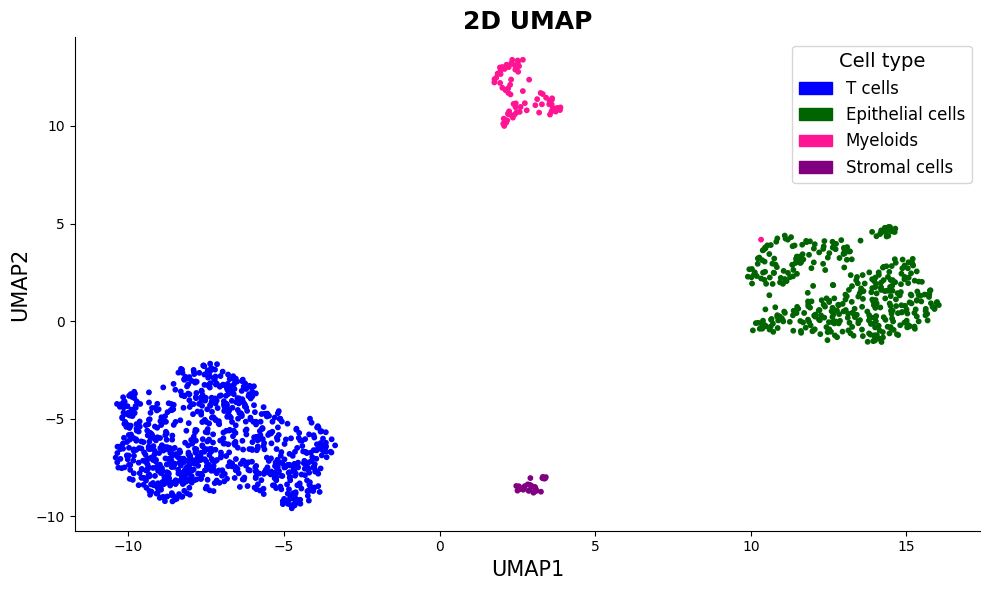

In [15]:
import matplotlib.pyplot as plt

# Define a color map for the cell types with specific colors
color_map = {
    'T cells': 'blue',  
    'Epithelial cells': 'darkgreen', 
    'Myeloids': 'deeppink',
    'Stromal cells': 'purple'
}

colors = umap_df['celltype'].map(color_map)
plt.figure(figsize=(10, 6))
plt.scatter(umap_df.iloc[:,0], umap_df.iloc[:,1], c = colors,s=10)

# Title and labels
plt.title('2D UMAP', fontsize=18, fontweight='bold')
plt.xlabel('UMAP1', fontsize=15)
plt.ylabel('UMAP2', fontsize=15)

# Customize legend
# Create legend patches for each cell type
from matplotlib.patches import Patch
legend_patches = [Patch(color=color_map[key], label=key) for key in color_map]
plt.legend(handles=legend_patches,title='Cell type', title_fontsize='14', fontsize='12', bbox_to_anchor=(1,1))
plt.tight_layout()

In [16]:
%%time
import palantir
dm_res = palantir.utils.run_diffusion_maps(ad_transposed, n_components=20)

CPU times: user 1.31 s, sys: 46.3 ms, total: 1.36 s
Wall time: 66.4 ms


In [17]:
%%time
## Run Mellon
model = mellon.DensityEstimator()
log_density = model.fit_predict(ad_transposed.obsm["DM_EigenVectors"])

predictor = model.predict

ad_transposed.obs["mellon_log_density"] = log_density
ad_transposed.obs["mellon_log_density_clipped"] = np.clip(
    log_density, *np.quantile(log_density, [0.05, 1])
)

[2026-08-25 00:23:00,853] [INFO    ] Using non-sparse Gaussian Process since n_landmarks (1,375) >= n_samples (1,375) and rank = 1.0.
[2026-08-25 00:23:00,854] [INFO    ] Computing nearest neighbor distances.
[2026-08-25 00:23:00,954] [INFO    ] Using embedding dimensionality d=20. Use d_method="fractal" to enable effective density normalization.
[2026-08-25 00:23:00,956] [INFO    ] Using covariance function Matern52(ls=0.25527188181877136).
[2026-08-25 00:23:00,957] [INFO    ] Computing Lp.
[2026-08-25 00:23:00,998] [INFO    ] Using rank 1,375 covariance representation.
[2026-08-25 00:23:01,048] [INFO    ] Running inference using L-BFGS-B.
[2026-08-25 00:23:02,005] [INFO    ] Computing predictive function.
CPU times: user 21.3 s, sys: 503 ms, total: 21.8 s
Wall time: 1.16 s


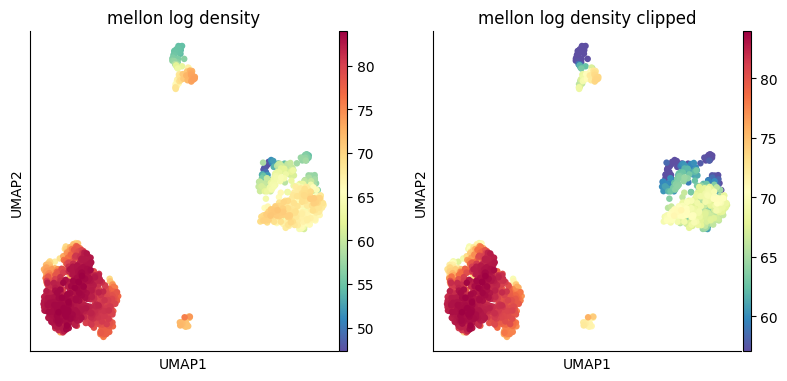

In [18]:
import matplotlib.pyplot as plt
with plt.rc_context():
    sc.pl.scatter(
        ad_transposed, color=["mellon_log_density", "mellon_log_density_clipped"], basis="umap",
        show = False
    )
plt.savefig(os.path.join(export_path,"Mellon density on UMAP 2d representation.pdf"), bbox_inches="tight")

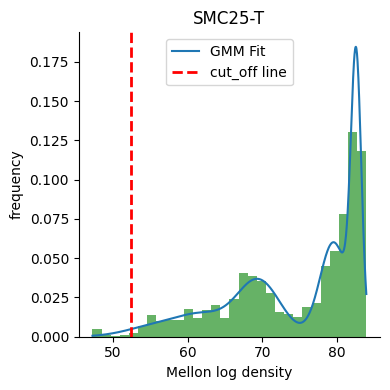

In [20]:
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from pathlib import Path

## Put the path of the folder where specialist and generalist cells are present after distance based method and in some case after reclustering.
path = os.chdir(os.path.join("/data/subhasis_backup/subhasis/pipeline_testing/specialist_generalist_with_cluster/", sample_name)) 
files = os.listdir(path)
specialist_generalist_files = []
for file in files:
    if file.endswith(".tsv") == True:
        specialist_generalist_files.append(file)
specialist_generalist_files.sort()

specialist_generalist_cells = []
for files in specialist_generalist_files:
    data = pd.read_csv(files, index_col=0, sep="\t")
    data.rename(columns = {'x': 'cells'}, inplace = True)
    specialist_generalist_cells.append(data) 

#global density cut_off estimation
global_data = ad_transposed.obs.mellon_log_density.values
global_data = global_data.reshape(-1, 1)

# Fit GMM with different numbers of components
n_components_range = range(1, 6)
models = [GaussianMixture(n_components=n, covariance_type='full').fit(global_data) for n in n_components_range]
bics = [model.bic(global_data) for model in models]

# Select the best model based on BIC
best_model_global = models[np.argmin(bics)]
best_n_components_global = best_model_global.n_components

# Extract means, covariances, and standard deviations for global sample
means_global = best_model_global.means_.flatten()
covariances_global = best_model_global.covariances_.flatten()
std_devs_global = np.sqrt(covariances_global)
if (best_n_components_global == 1):
    global_low_density_cut_off = means_global[0] - (3 * std_devs_global[0])
elif (best_n_components_global > 1):
    min_value_global = min(means_global)
    pos_global = np.argmin(means_global)
    global_low_density_cut_off = min_value_global - (1 * std_devs_global[pos_global])

x_global = np.linspace(min(global_data), max(global_data), 1000).reshape(-1, 1)
logprob_global = best_model_global.score_samples(x_global)
pdf_global = np.exp(logprob_global)

plt.hist(global_data, bins=30, density=True, alpha=0.6, color='g')
plt.plot(x_global, pdf_global, label='GMM Fit')
plt.title(f'{sample_name}')
plt.xlabel('Mellon log density')
plt.ylabel('frequency')
plt.axvline(x = global_low_density_cut_off, color='r', linestyle='--', linewidth=2, label='cut_off line')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(export_path,"Global mellon density distribution.pdf"), bbox_inches="tight")
plt.show()

density_specialist_generalist = []
for pop in specialist_generalist_cells:
    temp_density = ad_transposed.obs.loc[ad_transposed.obs.index.isin(pop.cells),:]
    temp_density = temp_density[temp_density.mellon_log_density > global_low_density_cut_off]
    density_specialist_generalist.append(temp_density)

high_density_cells= []
for j in range(len(density_specialist_generalist)):
    high_density = density_specialist_generalist[j]
    high_density['archetype'] = Path(specialist_generalist_files[j]).stem
    high_density_umap = umap_df.loc[umap_df.index.isin(high_density.index),:]
    high_density[['UMAP1','UMAP2']] = high_density_umap.loc[:, ['UMAP1', 'UMAP2']]
    cells = pd.DataFrame(high_density.index)
    cells.rename(columns = {0: 'cells'}, inplace = True)
    cells.to_csv(os.path.join(export_path,f"{os.path.splitext(specialist_generalist_files[j])[0]}_mellon_high_density_specialists_and_generalists.csv"))
    high_density_cells.append(high_density)

all_high_density_cells = pd.concat(high_density_cells, axis=0)

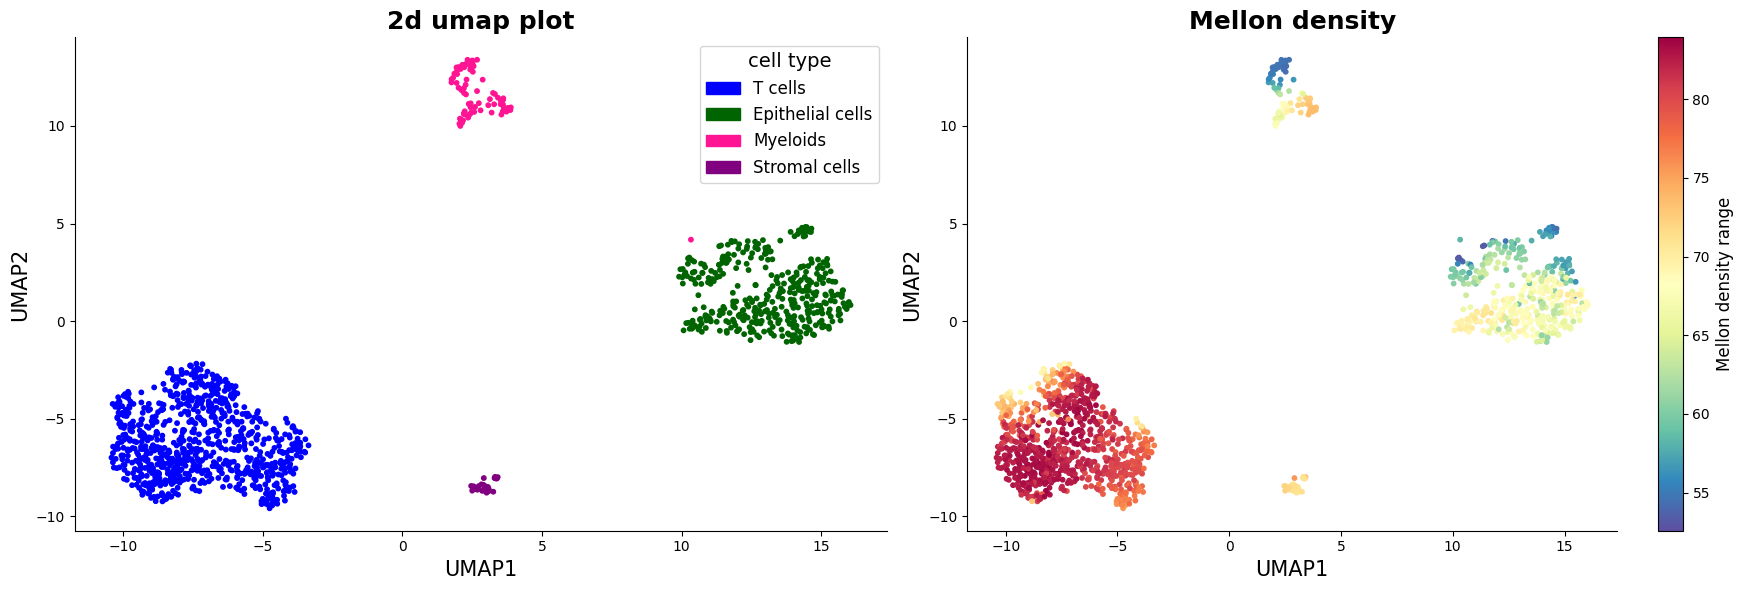

In [21]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))
color_map = {
    'T cells': 'blue',  
    'Epithelial cells': 'darkgreen', 
    'Myeloids': 'deeppink',
    'Stromal cells': 'purple'
}

colors = all_high_density_cells['Cell_type'].map(color_map)
ax[0].scatter(all_high_density_cells.iloc[:,4],all_high_density_cells.iloc[:,5], c = colors,s=10)
ax[0].set_title('2d umap plot', fontsize=18, fontweight='bold')
ax[0].set_xlabel('UMAP1', fontsize=15)
ax[0].set_ylabel('UMAP2', fontsize=15)

from matplotlib.patches import Patch
legend_patches = [Patch(color=color_map[key], label=key) for key in color_map]
ax[0].legend(handles= legend_patches, title = 'cell type', title_fontsize='14', fontsize='12', bbox_to_anchor=(1,1))
plt.tight_layout()

scatter = ax[1].scatter(all_high_density_cells.iloc[:,4], all_high_density_cells.iloc[:,5],
              c = all_high_density_cells.iloc[:,1], s=10)

colorbar = plt.colorbar(scatter)
colorbar.set_label('Mellon density range', fontsize=12)
ax[1].set_title('Mellon density', fontsize=18, fontweight='bold')
ax[1].set_xlabel('UMAP1', fontsize=15)
ax[1].set_ylabel('UMAP2', fontsize=15)
plt.tight_layout()
plt.savefig(os.path.join(export_path,"High density region matching with cell type.pdf"), bbox_inches="tight")

In [ ]:
np.unique(all_high_density_cells['archetype'])

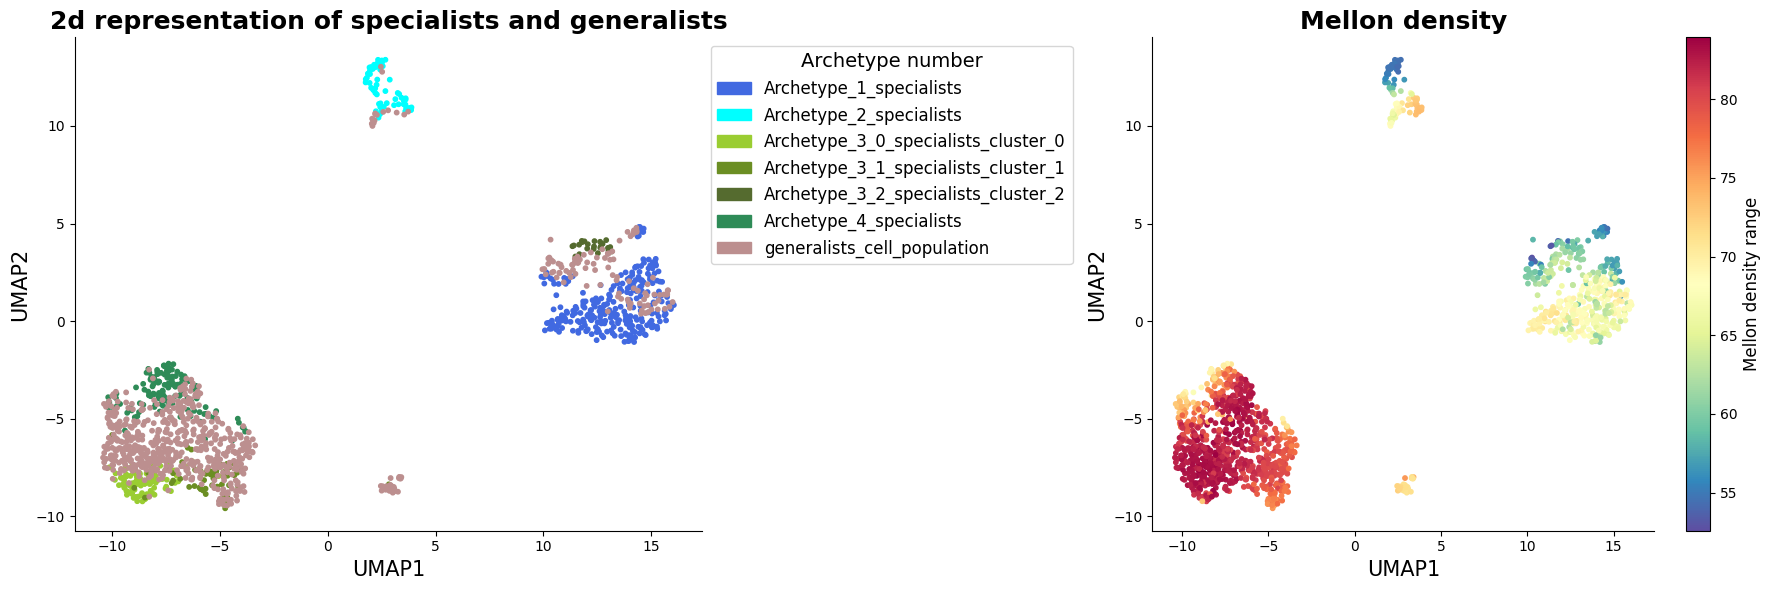

In [23]:
elements = np.unique(all_high_density_cells['archetype'])

## All the archetypes will be commented out except the archetypes are present here. Choose your specialists color accordingly.
color_map = {
    elements[0]: 'royalblue',  
    # elements[1]: 'cadetblue',
    elements[1]: 'cyan',
    # elements[3]: 'darkcyan',
    # elements[3]: 'skyblue',
    # elements[4]: 'steelblue',
    # elements[6]: 'dodgerblue',
    # elements[4]: 'lime',
    elements[2]: 'yellowgreen',
    elements[3]: 'olivedrab',
    elements[4]: 'darkolivegreen',
    # elements[4]: 'springgreen',
    # elements[4]: 'slategray',
    # elements[3]: hex_colors[0],
    # elements[4]: hex_colors[1],
    # elements[5]: hex_colors[2],
    # elements[6]: hex_colors[3],
    # elements[7]: hex_colors[4],
    # elements[8]: hex_colors[5],
    # elements[5]: 'forestgreen',
    elements[5]: 'seagreen',
    # elements[7]: 'darkgreen',
    # elements[5]: "#804040",
    # elements[9]: hex_colors[6],
    # elements[8]: 'purple',
    # elements[5]: 'peru',
    elements[6]: 'rosybrown'
}

colors = all_high_density_cells['archetype'].map(color_map)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))
ax[0].scatter(all_high_density_cells.iloc[:,4],all_high_density_cells.iloc[:,5],
              c=colors,s=10)

# Title and labels
ax[0].set_title('2d representation of specialists and generalists', fontsize=18, fontweight='bold')
ax[0].set_xlabel('UMAP1', fontsize=15)
ax[0].set_ylabel('UMAP2', fontsize=15)

#Customize legend
from matplotlib.patches import Patch
legend_patches = [Patch(color=color_map[key], label=key) for key in color_map]
ax[0].legend(handles= legend_patches, title = 'Archetype number', title_fontsize='14', fontsize='12', bbox_to_anchor=(1,1))
plt.tight_layout()

#plot mellon density side by side
#converting the density information dataframe to ann data object
scatter = ax[1].scatter(all_high_density_cells.iloc[:,4],all_high_density_cells.iloc[:,5],
              c=all_high_density_cells.iloc[:,1],s=10)

# Add the colorbar
colorbar = plt.colorbar(scatter)
colorbar.set_label('Mellon density range', fontsize=12)

# Title and labels
ax[1].set_title('Mellon density', fontsize=18, fontweight='bold')
ax[1].set_xlabel('UMAP1', fontsize=15)
ax[1].set_ylabel('UMAP2', fontsize=15)
plt.tight_layout()
plt.savefig(os.path.join(export_path,"density map matching with archetype number.pdf"), bbox_inches="tight")
plt.show()

## Map high density cell on ParTI space and color them celltype wise

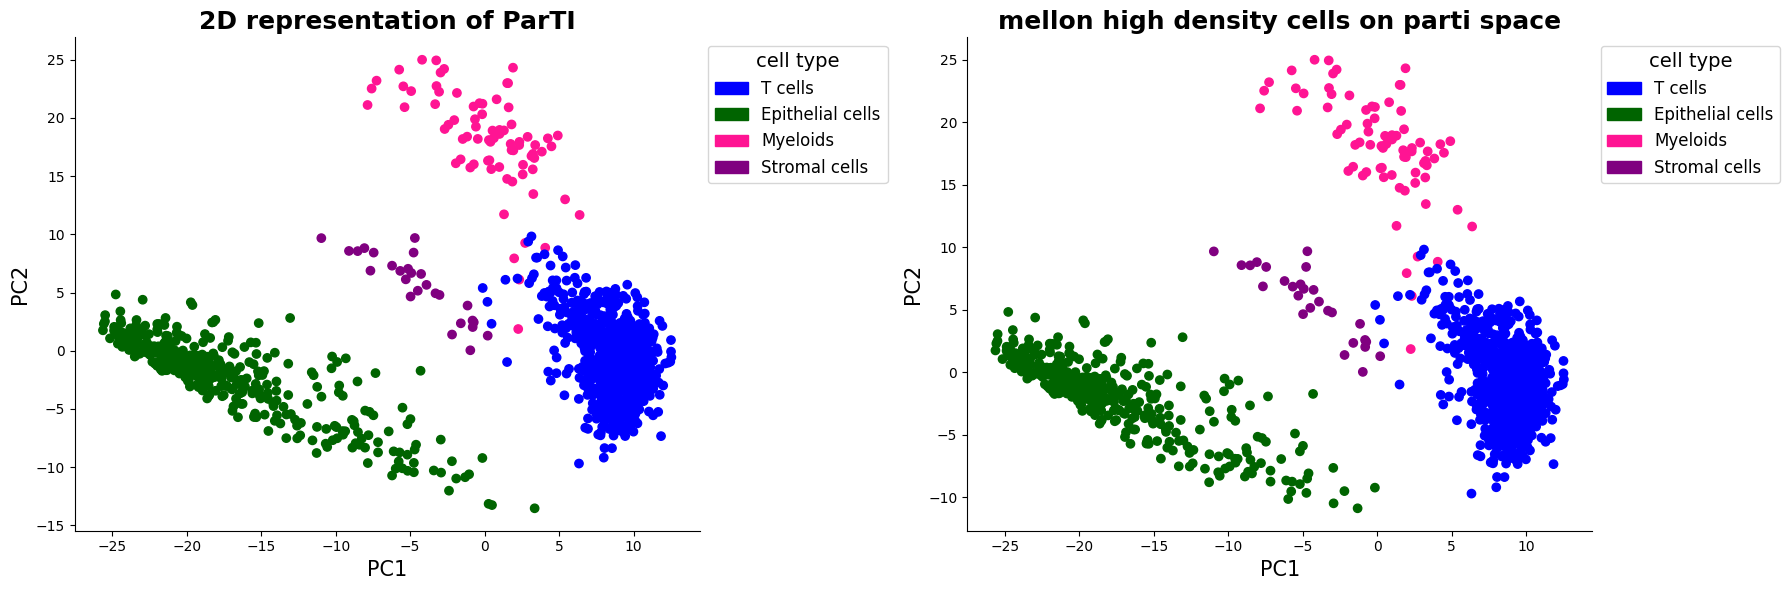

In [25]:
#plot the high density mapped specialists-generalist on parti space
import scipy.io
path = os.chdir(os.path.join("/data/subhasis_backup/subhasis/pipeline_testing/parti_result",sample_name))  ## Please put the path of the parti output folder of the sample
files = os.listdir(path)

parti_result = []
for file in files:
    if file.endswith(".mat") == True:
        parti_result.append(file)

parti_data = scipy.io.loadmat(parti_result[0])
parti_data.keys()
data = pd.DataFrame(parti_data["pc"])
data.index = celltype_data.index
data['cell_type'] = celltype_data['Cell_type']
high_density_mellon_cells = pd.merge(data, all_high_density_cells.iloc[:,0], left_index=True, right_index=True, how='left')
high_density_mellon_cells = high_density_mellon_cells.dropna()

#plot those high density cells on parti space and colored them according to celltype and 
#compare with actual parti data side by side
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

# Define a color map for the cell types with specific colors
color_map = {
    'T cells': 'blue',  
    'Epithelial cells': 'darkgreen', 
    'Myeloids': 'deeppink',
    'Stromal cells': 'purple'
}

colors = data['cell_type'].map(color_map)
ax[0].scatter(data.iloc[:,0],data.iloc[:,1],c=colors)
# Title and labels
ax[0].set_title('2D representation of ParTI', fontsize=18, fontweight='bold')
ax[0].set_xlabel('PC1', fontsize=15)
ax[0].set_ylabel('PC2', fontsize=15)

from matplotlib.patches import Patch
legend_patches = [Patch(color=color_map[key], label=key) for key in color_map]
ax[0].legend(handles= legend_patches, title = 'cell type', title_fontsize='14', fontsize='12', bbox_to_anchor=(1,1))
plt.tight_layout()

#map mellon's high density cells data on parti space
colors = high_density_mellon_cells['cell_type'].map(color_map)

ax[1].scatter(high_density_mellon_cells.iloc[:,0],high_density_mellon_cells.iloc[:,1],c=colors)
# Title and labels
ax[1].set_title('mellon high density cells on parti space', fontsize=18, fontweight='bold')
ax[1].set_xlabel('PC1', fontsize=15)
ax[1].set_ylabel('PC2', fontsize=15)

from matplotlib.patches import Patch
legend_patches = [Patch(color=color_map[key], label=key) for key in color_map]
ax[1].legend(handles= legend_patches, title = 'cell type', title_fontsize='14', fontsize='12', bbox_to_anchor=(1,1))
plt.tight_layout()
plt.savefig(os.path.join(export_path,"Mellon high density cells on ParTI space (celltype_based_coloring).pdf"), bbox_inches="tight")
plt.show()

## Map high density cells on ParTI space and color them Archetype wise

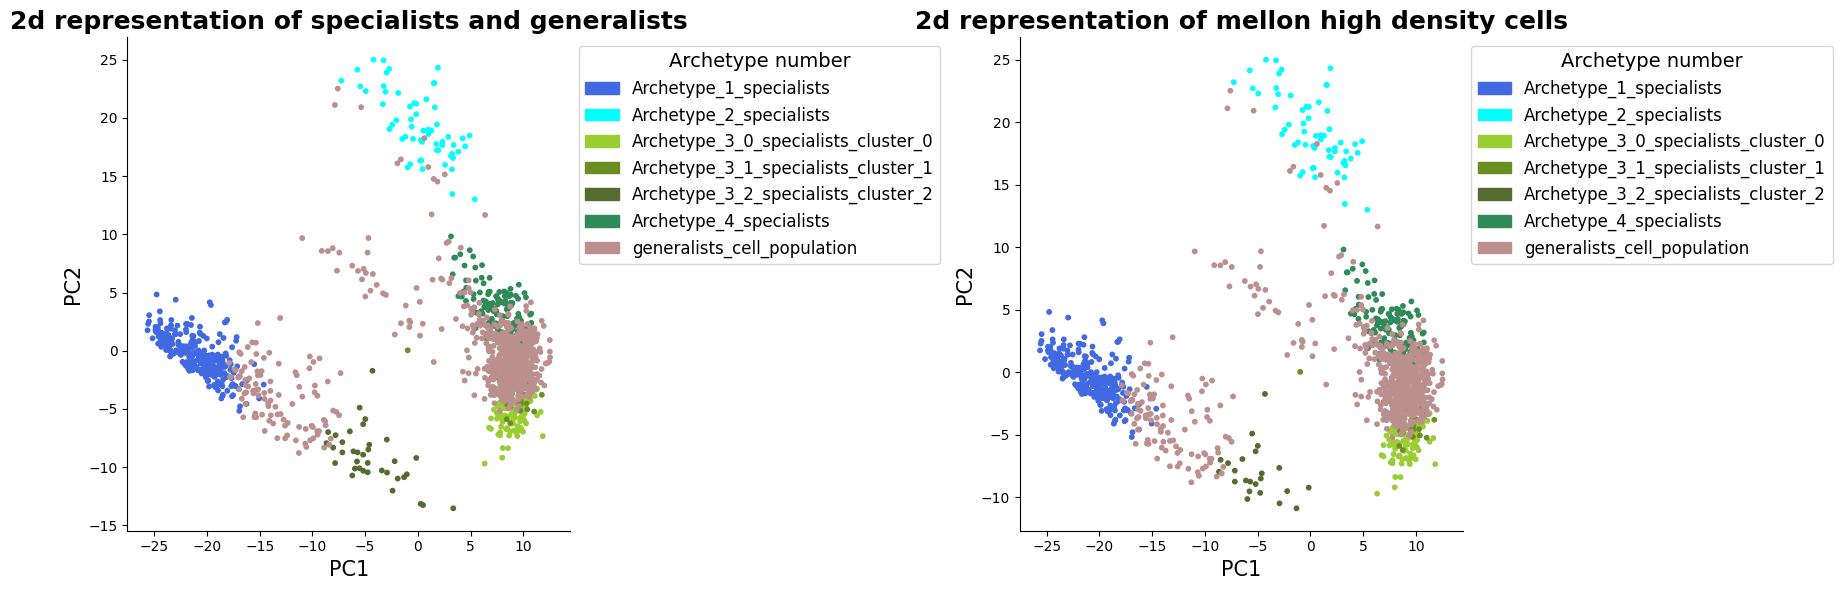

In [26]:
high_density_parti_cells = all_high_density_cells.merge(data.iloc[:, :3], left_index=True, right_index=True, how='inner')
high_density_parti_cells.to_csv(os.path.join(export_path,"high_density_cells_in_the_pareto_front.csv"))

all_specialist_generalist = []
for j,cells in enumerate(specialist_generalist_cells):
    cells['archetype'] = " ".join(os.path.splitext(specialist_generalist_files[j])[0].split()[:2])
    all_specialist_generalist.append(cells)
    
all_specialist_generalist_mod = pd.concat(all_specialist_generalist,axis=0)
all_specialist_generalist_mod.index = all_specialist_generalist_mod.cells
all_specialist_generalist_coordinates = all_specialist_generalist_mod.merge(data.iloc[:, :2], left_index=True, right_index=True, how='inner')

## All the archetypes will be commented out except the archetypes are present here
color_map = {
    elements[0]: 'royalblue',  
    # elements[1]: 'cadetblue',
    elements[1]: 'cyan',
    # elements[3]: 'darkcyan',
    # elements[3]: 'skyblue',
    # elements[4]: 'steelblue',
    # elements[6]: 'dodgerblue',
    # elements[4]: 'lime',
    elements[2]: 'yellowgreen',
    elements[3]: 'olivedrab',
    elements[4]: 'darkolivegreen',
    # elements[4]: 'springgreen',
    # elements[4]: 'slategray',
    # elements[3]: hex_colors[0],
    # elements[4]: hex_colors[1],
    # elements[5]: hex_colors[2],
    # elements[6]: hex_colors[3],
    # elements[7]: hex_colors[4],
    # elements[8]: hex_colors[5],
    # elements[5]: 'forestgreen',
    elements[5]: 'seagreen',
    # elements[7]: 'darkgreen',
    # elements[5]: "#804040",
    # elements[9]: hex_colors[6],
    # elements[8]: 'purple',
    # elements[5]: 'peru',
    elements[6]: 'rosybrown'
}

colors = all_specialist_generalist_coordinates['archetype'].map(color_map)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))
ax[0].scatter(all_specialist_generalist_coordinates.iloc[:,2], all_specialist_generalist_coordinates.iloc[:,3],
              c=colors,s=10)
ax[0].set_title('2d representation of specialists and generalists', fontsize=18, fontweight='bold')
ax[0].set_xlabel('PC1', fontsize=15)
ax[0].set_ylabel('PC2', fontsize=15)

from matplotlib.patches import Patch
legend_patches = [Patch(color=color_map[key], label=key) for key in color_map]
ax[0].legend(handles= legend_patches, title = 'Archetype number', title_fontsize='14', fontsize='12', bbox_to_anchor=(1,1))
plt.tight_layout()

#high density cell coloring based on archetypes
colors_1 = high_density_parti_cells['archetype'].map(color_map)
ax[1].scatter(high_density_parti_cells.iloc[:,6],high_density_parti_cells.iloc[:,7],c=colors_1,s=10)
ax[1].set_title('2d representation of mellon high density cells', fontsize=18, fontweight='bold')
ax[1].set_xlabel('PC1', fontsize=15)
ax[1].set_ylabel('PC2', fontsize=15)

from matplotlib.patches import Patch
legend_patches = [Patch(color=color_map[key], label=key) for key in color_map]
ax[1].legend(handles= legend_patches, title = 'Archetype number', title_fontsize='14', fontsize='12', bbox_to_anchor=(1,1))
plt.tight_layout()
plt.savefig(os.path.join(export_path,"Mellon high density cells on ParTI space (Archetype based coloring).pdf"), bbox_inches="tight")
plt.show()

## Final mellon derived cells colored with archetypes specialists and generalists

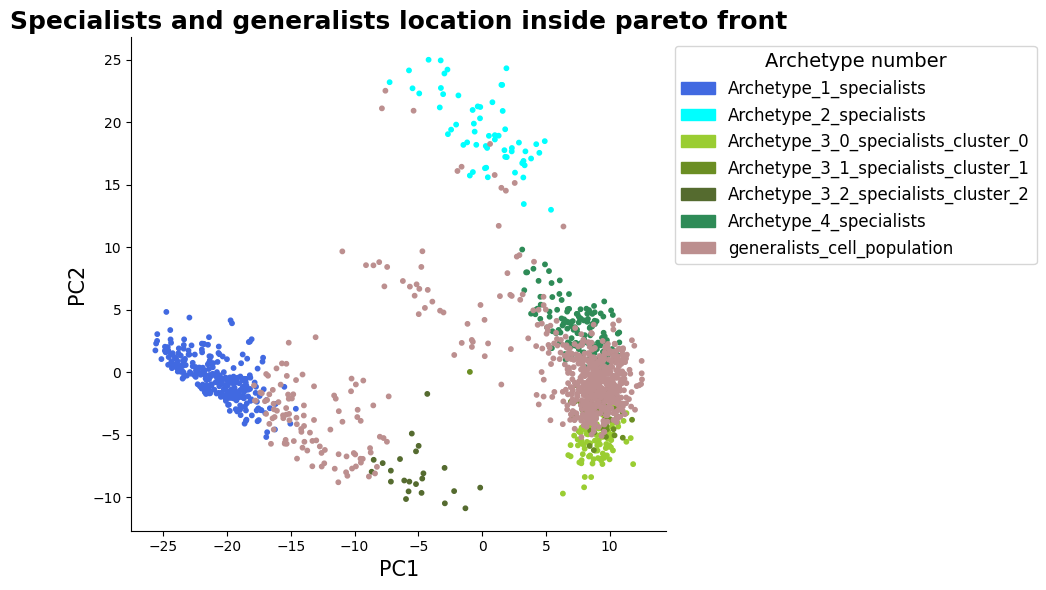

In [27]:
plt.figure(figsize=(10,6))
colors_1 = high_density_parti_cells['archetype'].map(color_map)
plt.scatter(high_density_parti_cells.iloc[:,6],high_density_parti_cells.iloc[:,7],c=colors_1,s=10)
plt.title('Specialists and generalists location inside pareto front', fontsize=18, fontweight='bold')
plt.xlabel('PC1', fontsize=15)
plt.ylabel('PC2', fontsize=15)

from matplotlib.patches import Patch
legend_patches = [Patch(color=color_map[key], label=key) for key in color_map]
plt.legend(handles= legend_patches, title = 'Archetype number', title_fontsize='14', fontsize='12', bbox_to_anchor=(1,1))
plt.tight_layout()
plt.savefig(os.path.join(export_path,"Mellon derived archetypes based pareto front.pdf"), bbox_inches="tight", dpi=300)
plt.show()

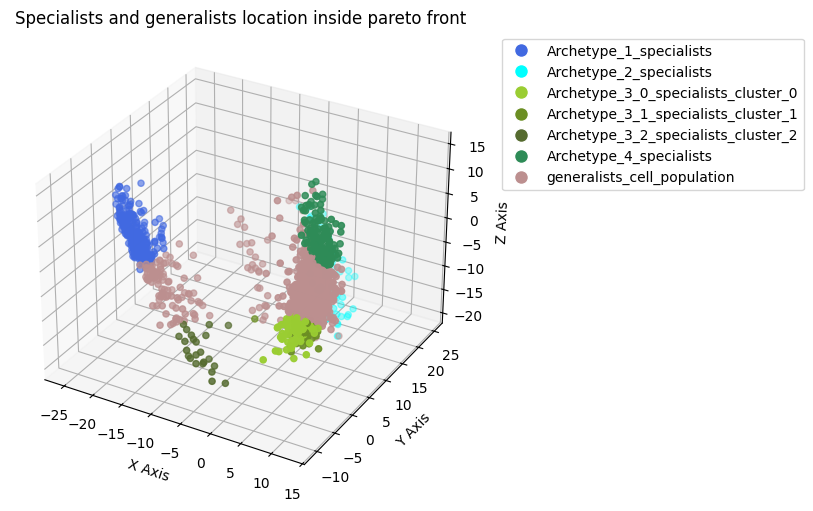

In [28]:
## 3d plot
from matplotlib.lines import Line2D

high_density_parti_cells['color']= high_density_parti_cells['archetype'].map(color_map)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    high_density_parti_cells.iloc[:, 6],
    high_density_parti_cells.iloc[:, 7],
    high_density_parti_cells.iloc[:, 8],
    c=colors_1,  # your custom colors
    marker='o'
)
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')
ax.set_title('Specialists and generalists location inside pareto front')
unique_labels = high_density_parti_cells['archetype'].unique()

legend_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=color_map[label],
        label=label,
        markersize=10
    )
    for label in unique_labels
]
ax.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1.05, 1))
plt.savefig(os.path.join(export_path,"Mellon derived archetypes based pareto front 3D.pdf"), bbox_inches="tight", dpi=300)
plt.show()

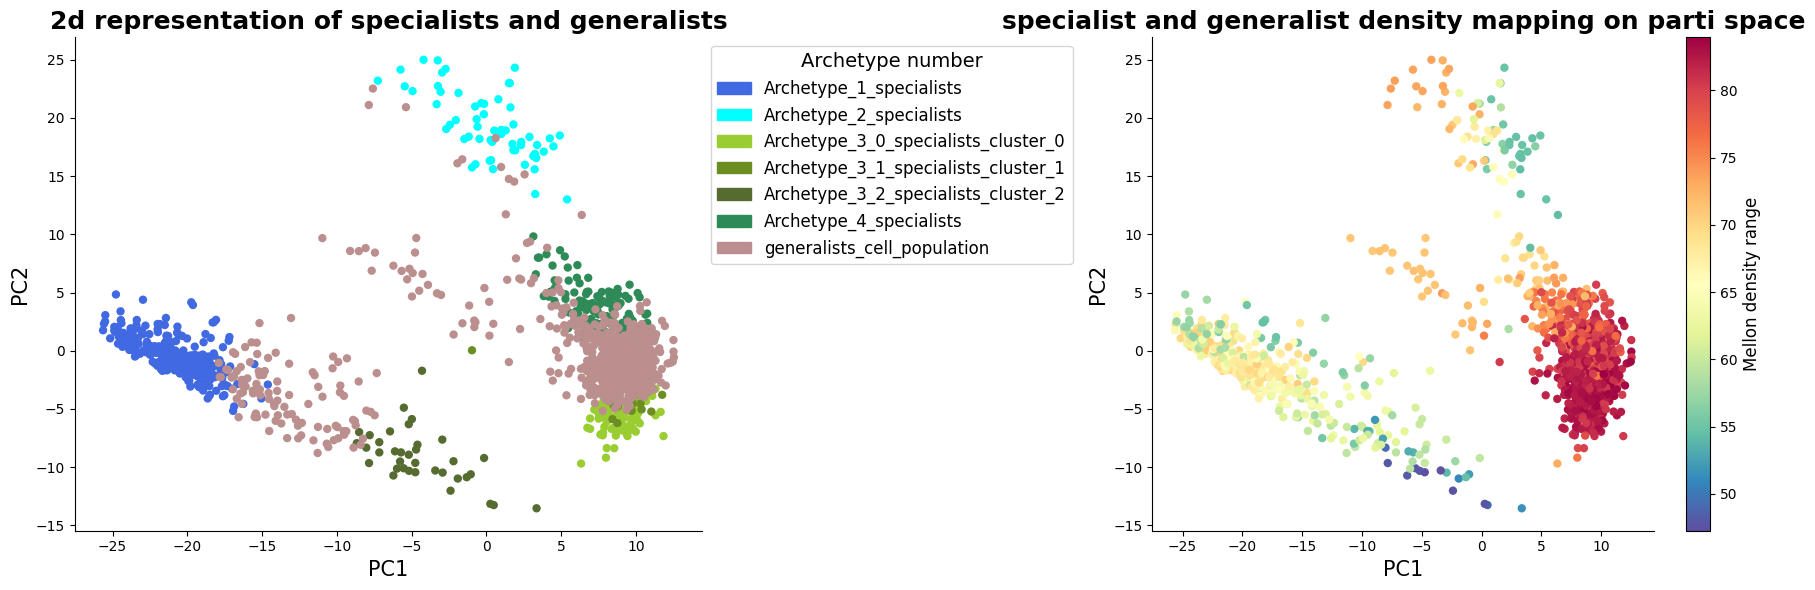

In [29]:
all_specialist_generalist_coordinates = all_specialist_generalist_coordinates.merge(ad_transposed.obs.iloc[:,1], left_index=True, right_index=True, how='inner')

## All the archetypes will be commented out except the archetypes are present here
color_map = {
    elements[0]: 'royalblue',  
    # elements[1]: 'cadetblue',
    elements[1]: 'cyan',
    # elements[3]: 'darkcyan',
    # elements[3]: 'skyblue',
    # elements[4]: 'steelblue',
    # elements[6]: 'dodgerblue',
    # elements[4]: 'lime',
    elements[2]: 'yellowgreen',
    elements[3]: 'olivedrab',
    elements[4]: 'darkolivegreen',
    # elements[4]: 'springgreen',
    # elements[4]: 'slategray',
    # elements[3]: hex_colors[0],
    # elements[4]: hex_colors[1],
    # elements[5]: hex_colors[2],
    # elements[6]: hex_colors[3],
    # elements[7]: hex_colors[4],
    # elements[8]: hex_colors[5],
    # elements[5]: 'forestgreen',
    elements[5]: 'seagreen',
    # elements[7]: 'darkgreen',
    # elements[5]: "#804040",
    # elements[9]: hex_colors[6],
    # elements[8]: 'purple',
    # elements[5]: 'peru',
    elements[6]: 'rosybrown'
}
colors = all_specialist_generalist_coordinates['archetype'].map(color_map)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))
ax[0].scatter(all_specialist_generalist_coordinates.iloc[:,2],all_specialist_generalist_coordinates.iloc[:,3],
              c=colors,s=25)
ax[0].set_title('2d representation of specialists and generalists', fontsize=18, fontweight='bold')
ax[0].set_xlabel('PC1', fontsize=15)
ax[0].set_ylabel('PC2', fontsize=15)

from matplotlib.patches import Patch
legend_patches = [Patch(color=color_map[key], label=key) for key in color_map]
ax[0].legend(handles= legend_patches, title = 'Archetype number', title_fontsize='14', fontsize='12', bbox_to_anchor=(1,1))
plt.tight_layout()


#plotting density for only specialist and generalists
all_specialist_generalist_coordinates.rename(columns = {0: 'PC1'}, inplace = True)
all_specialist_generalist_coordinates.rename(columns = {1: 'PC2'}, inplace = True)
scatter= ax[1].scatter('PC1', 'PC2', data = all_specialist_generalist_coordinates, c='mellon_log_density', s=25)
colorbar = plt.colorbar(scatter)
colorbar.set_label('Mellon density range', fontsize=12)
ax[1].set_title('specialist and generalist density mapping on parti space', fontsize=18, fontweight='bold')
ax[1].set_xlabel('PC1', fontsize=15)
ax[1].set_ylabel('PC2', fontsize=15)
plt.tight_layout()
plt.savefig(os.path.join(export_path,"Mellon density mapped on parti space for specialists and generalist.pdf"), bbox_inches="tight")
plt.show()

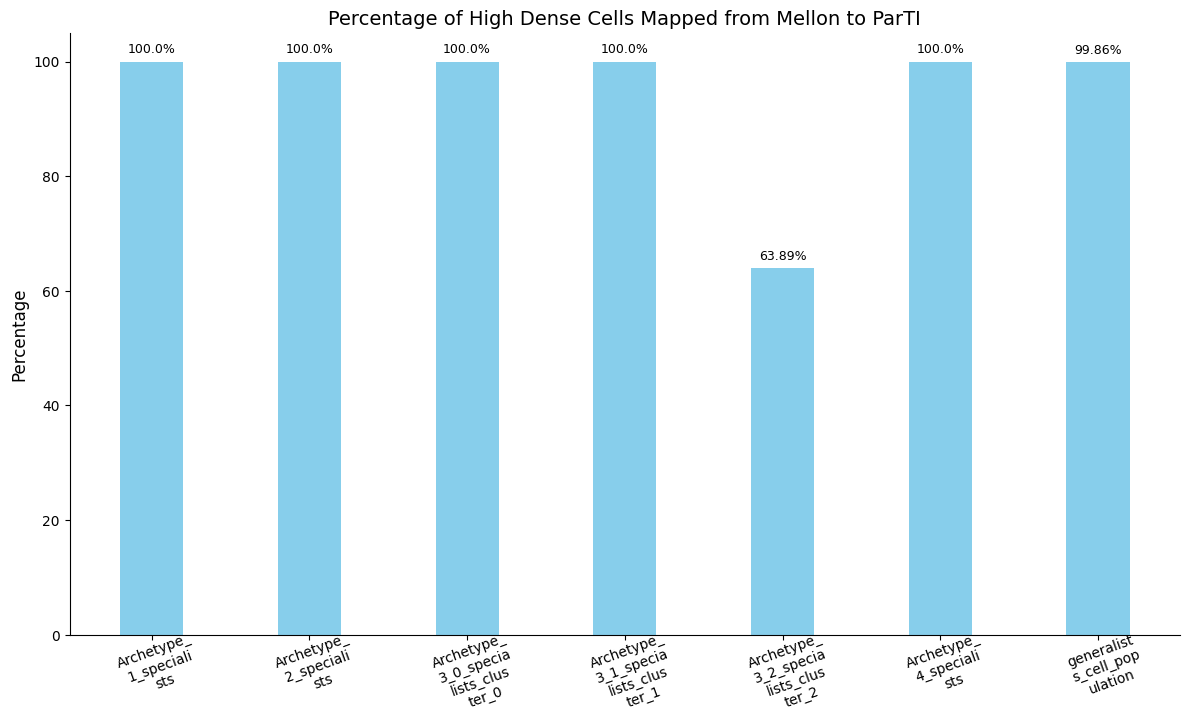

In [30]:
import matplotlib.pyplot as plt
import os
import textwrap

mellon_mapped_on_parti = []
specialist_generalist = []
for i in range(len(specialist_generalist_files)):
    cell_num_parti = specialist_generalist_cells[i].shape[0]
    cell_num_mellon = high_density_cells[i].shape[0]
    mapped_cell_percentage = round((cell_num_mellon / cell_num_parti) * 100, 2)
    mellon_mapped_on_parti.append(mapped_cell_percentage)
    names = os.path.splitext(specialist_generalist_files[i])[0]
    specialist_generalist.append(names)

wrapped_specialist_generalist = [textwrap.fill(name, width=10) for name in specialist_generalist]

plt.figure(figsize=(12, 8))
bars = plt.bar(wrapped_specialist_generalist, mellon_mapped_on_parti, color='skyblue', width=0.4)

for bar in bars:
    yval = bar.get_height()  
    plt.text(
        bar.get_x() + bar.get_width() / 2,  
        yval + 1,  
        f'{yval}%',  
        ha='center',  
        va='bottom',  
        fontsize=9,  
        color='black'  
    )

plt.xticks(fontsize=10, rotation=20, ha='center', rotation_mode='anchor') 
plt.ylabel("Percentage", fontsize=12)
plt.title("Percentage of High Dense Cells Mapped from Mellon to ParTI", fontsize=14)
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
plt.savefig(os.path.join(export_path, "percentage_of_cells_mapped_from_mellon_to_parti_specialist_generalist.pdf"), bbox_inches="tight")
plt.show()

In [31]:
ad_transposed

AnnData object with n_obs × n_vars = 1375 × 33694
    obs: 'Cell_type', 'mellon_log_density', 'mellon_log_density_clipped'
    uns: 'pca', 'neighbors', 'umap', 'DM_EigenValues'
    obsm: 'X_pca', 'X_umap', 'DM_EigenVectors'
    varm: 'PCs'
    obsp: 'distances', 'connectivities', 'DM_Kernel', 'DM_Similarity'

In [33]:
ad_transposed.write_h5ad(f"{export_path}/{sample_name}_mellon.h5ad", compression="gzip")